# ElectInfo pulls TX boundaries for the 2026 cycle

## What this shows
How to fetch US Census TIGER geographies through the `BoundaryProvider` registry — state, counties, tracts — and (with a Census API key) pull ACS 2022 median income onto Travis County tracts for a map preview. This is the canonical entry point for any ElectInfo spatial work.

## Why it matters
Downstream notebooks (`spatial/02_geocoding`, `spatial/03_choropleth_maps`, `spatial/04_redistricting`) all consume geographies fetched the same way. One API, one caching path, one place to update when a Census vintage rolls.

## Prereqs
- `pip install 'siege-utilities[geo]'`
- Optional: `CENSUS_API_KEY` env var for the ACS demographics cell.
- Spatial data is cached by the library's CensusDataSource on first download — no fixtures committed to the repo.

## Next
- `spatial/02_geocoding.ipynb` — resolve donor / voter addresses to tracts in these geographies.
- `spatial/03_choropleth_maps.ipynb` — render what we fetched here as a bivariate choropleth.


## 1. Resolve the right provider for the country

`resolve_boundary_provider('US')` returns a `CensusTIGERProvider`; for non-US work you'd get `GADMProvider` instead. The surface is identical — `get_boundary(level, identifier=...)` — which keeps `spatial/01` and any international variant parallel.

In [1]:
from siege_utilities.geo.providers.boundary_providers import resolve_boundary_provider

tiger = resolve_boundary_provider('US')
print('provider        :', tiger.provider_name)
print('available levels:', tiger.list_levels())


provider        : Census TIGER/Line
available levels: ['block', 'block_group', 'cbsa', 'cd', 'county', 'cousub', 'division', 'nation', 'place', 'puma', 'region', 'sldl', 'sldu', 'state', 'tabblock10', 'tabblock20', 'tract', 'vtd', 'vtd20', 'zcta']


## 2. Fetch the Texas state polygon

State FIPS `48` = Texas. With no `identifier` argument `get_boundary('state')` pulls every state in one shot — we filter to Texas afterward.

In [2]:
states = tiger.get_boundary('state', year=2024)
print(f'all US states    : {len(states)} rows')

tx = states[states['statefp'] == '48'].copy() if states is not None else None
print(f'Texas polygon    : {len(tx)} row' if tx is not None else 'Texas fetch returned None')
tx.head(1) if tx is not None else 'Texas fetch returned None'


[siege_utilities] 2026-04-24 17:17:37,249 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-04-24 17:17:37,440 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-04-24 17:17:37,573 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip


[siege_utilities] 2026-04-24 17:17:37,711 INFO: Downloading state boundaries for year 2024


[siege_utilities] 2026-04-24 17:17:37,711 INFO: Downloading TIGER/Line data from: https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip


...

[siege_utilities] 2026-04-24 17:17:38,158 INFO: Successfully downloaded https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip to /Users/dheerajchand/Downloads/siege_utilities/tl_2024_us_state.zip


[siege_utilities] 2026-04-24 17:17:38,213 INFO: Extracted /Users/dheerajchand/Downloads/siege_utilities/tl_2024_us_state.zip to /Users/dheerajchand/Downloads/siege_utilities/tl_2024_us_state


[siege_utilities] 2026-04-24 17:17:38,994 INFO: Successfully processed state boundaries: 56 features


all US states    : 56 rows
Texas polygon    : 1 row


,region,division,statefp,statens,geoid,geoidfq,stusps,name,lsad,mtfcc,funcstat,aland,awater,intptlat,intptlon,geometry,census_year,geographic_level
25,3,7,48,01779801,48,0400000US48,TX,Texas,00,G4000,A,676656702022,19011620342,+31.4347032,-099.2818238,"POLYGON ((-98.42353 34.08284, -98.42235 34.082...",None,state


## 3. Fetch all Texas counties

Pass the state FIPS as `identifier`. ElectInfo's Q1 engagement cares most about Travis, Harris, and Dallas, so we filter to those three.

In [3]:
tx_counties = tiger.get_boundary('county', identifier='48', year=2024)
print(f'all TX counties : {len(tx_counties)} rows')

focus_fips = {'453': 'Travis', '201': 'Harris', '113': 'Dallas'}
focus = tx_counties[tx_counties['countyfp'].isin(focus_fips)].copy()
focus['county_name'] = focus['countyfp'].map(focus_fips)
focus[['geoid', 'name', 'county_name']]


[siege_utilities] 2026-04-24 17:17:39,268 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-04-24 17:17:39,268 INFO: Normalized '48' to FIPS 48: Texas (TX)


[siege_utilities] 2026-04-24 17:17:39,398 INFO: Constructing URL for Texas (TX)


[siege_utilities] 2026-04-24 17:17:39,399 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip


[siege_utilities] 2026-04-24 17:17:39,511 INFO: Downloading county boundaries for year 2024


...

[siege_utilities] 2026-04-24 17:17:42,465 INFO: Extracted /Users/dheerajchand/Downloads/siege_utilities/tl_2024_us_county.zip to /Users/dheerajchand/Downloads/siege_utilities/tl_2024_us_county


[siege_utilities] 2026-04-24 17:17:46,362 INFO: Successfully processed county boundaries: 3235 features


[siege_utilities] 2026-04-24 17:17:46,365 INFO: Filtered county from 3235 to 254 features for state 48


all TX counties : 254 rows


,geoid,name,county_name
1318,48201,Harris,Harris
2498,48113,Dallas,Dallas
3203,48453,Travis,Travis


## 4. Zoom in: Travis County tracts

The ACS demographics in the next cell need tract-level geography. Passing `identifier='48'` returns tracts for every Texas county, so we filter to Travis (`COUNTYFP == '453'`).

In [4]:
tx_tracts = tiger.get_boundary('tract', identifier='48', year=2024)
travis_tracts = tx_tracts[tx_tracts['countyfp'] == '453'].copy() if tx_tracts is not None else None
print(f'Travis County tracts: {len(travis_tracts)}' if travis_tracts is not None else 'tract fetch returned None')


[siege_utilities] 2026-04-24 17:17:46,568 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-04-24 17:17:46,568 INFO: Normalized '48' to FIPS 48: Texas (TX)


[siege_utilities] 2026-04-24 17:17:46,765 INFO: Constructing URL for Texas (TX)


[siege_utilities] 2026-04-24 17:17:46,766 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_48_tract.zip


[siege_utilities] 2026-04-24 17:17:47,488 INFO: Downloading tract boundaries for year 2024


...

tl_2024_48_tract.zip: 100%|##########| 32.6M/32.6M [00:00<00:00, 32.9MB/s]

[siege_utilities] 2026-04-24 17:17:48,589 INFO: Successfully downloaded https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_48_tract.zip to /Users/dheerajchand/Downloads/siege_utilities/tl_2024_48_tract.zip


[siege_utilities] 2026-04-24 17:17:48,728 INFO: Extracted /Users/dheerajchand/Downloads/siege_utilities/tl_2024_48_tract.zip to /Users/dheerajchand/Downloads/siege_utilities/tl_2024_48_tract


[siege_utilities] 2026-04-24 17:17:50,154 INFO: Successfully processed tract boundaries: 6896 features


Travis County tracts: 290


## 5. Attach ACS median household income (requires `CENSUS_API_KEY`)

`CensusAPIClient.fetch_data` queries the Census Bureau's ACS endpoint. `B19013_001E` is the standard median household income variable. Without a key we skip the join and note the gap — the map in the next cell still renders, just without the income overlay.

In [5]:
import os
from siege_utilities.geo.census_api_client import CensusAPIClient

api_key = os.environ.get('CENSUS_API_KEY')
if api_key and travis_tracts is not None:
    client = CensusAPIClient(api_key=api_key)
    income = client.fetch_data(
        variables='B19013_001E',
        year=2022,
        dataset='acs5',
        geography='tract',
        state_fips='48',
        county_fips='453',
        include_moe=True,
    )
    travis_tracts = travis_tracts.merge(
        income[['GEOID', 'B19013_001E']], on='geoid', right_on='GEOID', how='left',
    )
    travis_tracts = travis_tracts.rename(columns={'B19013_001E': 'median_income'})
    print(f'joined income onto {travis_tracts["median_income"].notna().sum()} / {len(travis_tracts)} tracts')
else:
    print('CENSUS_API_KEY not set — rendering preview without income overlay')


CENSUS_API_KEY not set — rendering preview without income overlay


## 6. Preview map

A GeoPandas plot is fine for a sanity-check preview. Fully-styled bivariate choropleths live in `spatial/03_choropleth_maps.ipynb`.

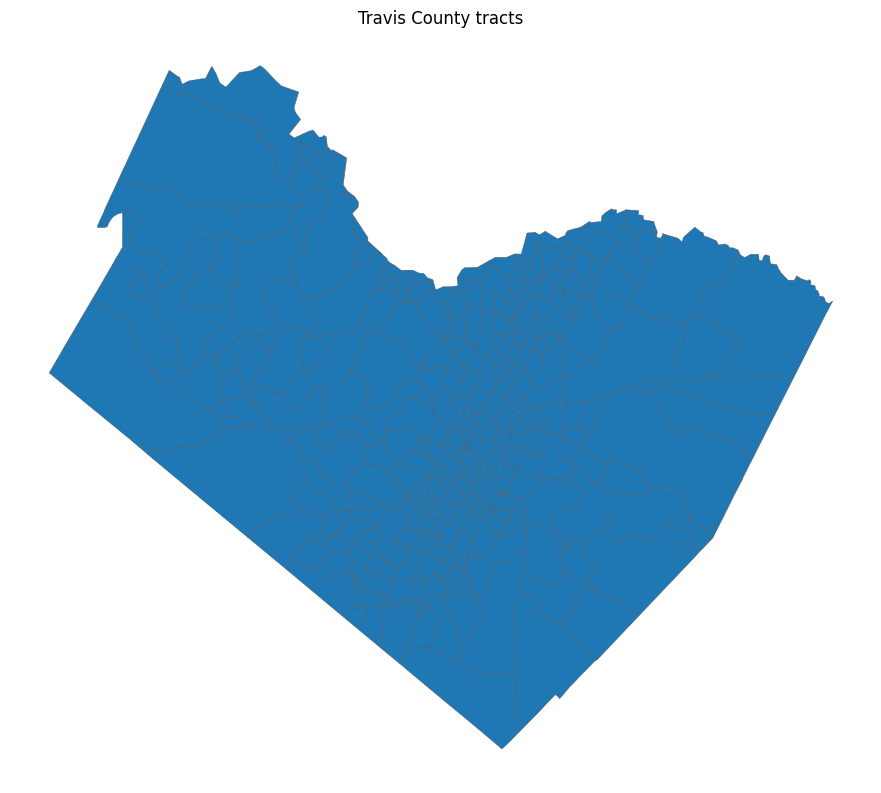

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))
if travis_tracts is not None:
    col = 'median_income' if 'median_income' in travis_tracts.columns else None
    travis_tracts.plot(
        ax=ax,
        column=col,
        cmap='YlOrRd' if col else None,
        edgecolor='#555555',
        linewidth=0.3,
        legend=bool(col),
    )
    ax.set_title('Travis County tracts' + (f' — {col}' if col else ''))
else:
    ax.set_title('Travis tracts unavailable (fetch returned None)')
ax.set_axis_off()
fig.tight_layout()


## Related

- **Source**: `siege_utilities/geo/providers/boundary_providers.py` (registry + TIGER + GADM + RDH), `siege_utilities/geo/census_api_client.py` (ACS fetches).
- **Tests**: `tests/test_boundary_providers*.py`, `tests/test_census_api_client*.py`.
- **Next**: `spatial/02_geocoding.ipynb` resolves addresses to tracts like the ones above.
- **ADR**: `docs/adr/0003-boundary-provider-registry.md` for why TIGER / GADM / RDH share one interface.
